# Notebook 2 Generating a Transient Population

In this notebook we generate a mixed population of supernovae (SN) and kilonovae (KN) 
within the synthetic universe constructed in Notebook 1.

We assume:

- Supernova rate ∝ Star Formation Rate (SFR)
- Kilonova rate ∝ Total Stellar Mass (M_star)
- Absolute magnitude M = -16 for both populations
- Survey duration T = 50,000 years

This notebook produces an intrinsic transient population and computes 
their apparent magnitudes using the distance modulus.

In [241]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


## Load Synthetic Galaxy Catalogue

We import the galaxy catalogue generated in Notebook 1.

This catalogue contains:

- Distance (Mpc)
- Stellar Mass (M_star)
- Star Formation Rate (SFR)
- Galaxy properties

In [242]:
galaxies = pd.read_csv("galaxy_catalog.csv")

print("Number of galaxies:", len(galaxies))
galaxies.head()


Number of galaxies: 50000


,x,y,z,distance,M_star,SFR,is_quiescent,L
0,-135.980529,-75.625049,-150.179101,216.248964,1.166272e+10,0.002688,True,0.009308
1,-290.744878,-49.749084,3.234814,294.988169,5.648145e+09,0.001249,True,0.001237
2,-127.169016,172.656237,164.673388,270.369118,5.612331e+09,0.007538,True,0.002440
3,-222.527760,9.495705,-119.665529,252.841079,5.976691e+09,0.001379,True,0.001037
4,-105.454176,119.467975,26.267419,161.502811,3.702149e+09,0.001622,True,0.001927


## Physical Event Rates

We assume simple host galaxy scaling relations.

The supernova rate in each galaxy is proportional to its star formation rate.

The kilonova rate in each galaxy is proportional to its stellar mass.

---

### Assumptions

- Core collapse supernovae trace ongoing star formation.
- Kilonovae trace stellar mass as a proxy for delayed mergers.
- Rates are constant over the survey duration.

Survey duration: 50,000 years.

---

### Normalizations

Supernova normalization: 1 × 10^-6 events per (M☉/yr) per year of star formation.

Kilonova normalization: 1 × 10^-18 events per year per solar mass of stellar mass.

These values reproduce realistic order-of-magnitude local event rates.

In [243]:
A_SN = 1e-6       # SN per (Msun/yr) per year
A_KN = 1e-18      # KN per Msun per year
T_survey = 50000.0     # years

## Sampling Event Counts

For each galaxy, we compute the expected number of events over the survey duration.

The expected supernova count scales with star formation rate.

The expected kilonova count scales with stellar mass.

Actual event numbers are drawn from a Poisson distribution with these expected values as the mean.

The expected totals represent the ensemble average.

The realised totals represent one Monte Carlo survey realisation.

In [244]:
lambda_SN = A_SN * galaxies["SFR"] * T_survey
lambda_KN = A_KN * galaxies["M_star"] * T_survey

N_SN = np.random.poisson(lambda_SN)
N_KN = np.random.poisson(lambda_KN)

print("Total expected SN:", lambda_SN.sum())
print("Total expected KN:", lambda_KN.sum())

print("Total realised SN:", N_SN.sum())
print("Total realised KN:", N_KN.sum())

Total expected SN: 504.6184724113488
Total expected KN: 13.983174577575706
Total realised SN: 507
Total realised KN: 17


## Construct Event Catalogue

We expand galaxy level event counts into an event-level table.

Each event stores:

- Event type (SN or KN)
- Host galaxy distance

This produces the intrinsic transient population.

In [245]:
events = []

for i in range(len(galaxies)):
    d = galaxies["distance"].iloc[i]

    for _ in range(N_SN[i]):
        events.append({"type": "SN", "distance": d})

    for _ in range(N_KN[i]):
        events.append({"type": "KN", "distance": d})

events = pd.DataFrame(events)

print("Total SN:", (events["type"] == "SN").sum())
print("Total KN:", (events["type"] == "KN").sum())
print("Total events:", len(events))


Total SN: 507
Total KN: 17
Total events: 524


## Convert to Apparent Magnitude

We assume a fixed absolute magnitude:

M = -16

The distance modulus is:

μ = 5 log10(d_Mpc) + 25

The apparent magnitude is:

m = M + μ



In [246]:
M_abs = -16

events["mu"] = 5 * np.log10(events["distance"]*1e6) - 5
events["m"] = M_abs + events["mu"]

events.head()

,type,distance,mu,m
0,SN,245.305339,36.948535,20.948535
1,SN,163.854689,36.072294,20.072294
2,SN,163.854689,36.072294,20.072294
3,SN,211.603041,36.627610,20.627610
4,SN,216.312545,36.675409,20.675409


### Brightness Range of Injected Events

This cell computes the apparent magnitude range of the simulated transient population.

- The minimum value of `m` corresponds to the brightest detected event.
- The maximum value of `m` corresponds to the faintest detected event.

This provides a quick validation that the injected supernovae and kilonovae span a physically reasonable magnitude range within the survey limits.


In [247]:
print("Brightest event:", events["m"].min())
print("Faintest event:", events["m"].max())

Brightest event: 17.423865625623314
Faintest event: 21.383146726788297


### Apparent Magnitude as a Function of Distance

This cell compares the simulated events to the theoretical distance–magnitude relation.

- A smooth distance grid `d` is created between the minimum and maximum event distances.


  where an absolute magnitude of M = -16 is assumed.
- The simulated event magnitudes are plotted as scatter points.
- The theoretical curve is overlaid for comparison.
- The y-axis is inverted because lower magnitudes correspond to brighter objects.

This verifies that the injected events follow the expected luminosity–distance scaling.


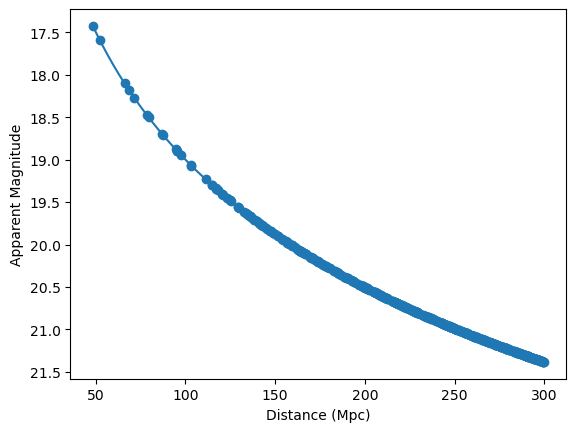

In [248]:

d = np.linspace(events["distance"].min(), 
                events["distance"].max(), 500)

m_model = -16 + 5*np.log10(d*1e6) - 5

plt.figure()
plt.scatter(events["distance"], events["m"])
plt.plot(d, m_model)

plt.xlabel("Distance (Mpc)")
plt.ylabel("Apparent Magnitude")
plt.gca().invert_yaxis()
plt.show()

### Apparent Magnitude Distribution: Supernovae vs Kilonovae

This cell compares the apparent magnitude distributions of Supernovae (SN) and Kilonovae (KN).

- The events are separated by type (`SN` and `KN`).
- Histograms of their apparent magnitudes (`m`) are plotted.
- A logarithmic y-axis is used to clearly show differences in event counts.
- This highlights the relative abundance of SN compared to the much rarer KN population.

The plot allows a direct visual comparison of brightness distributions and population imbalance between the two transient types.


[]

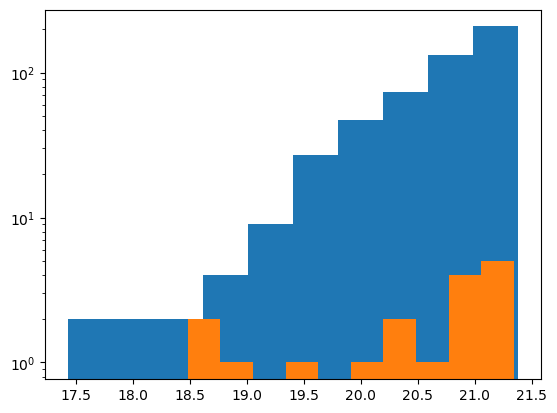

In [249]:
plt.hist(events[events['type']=='SN']['m'], label='SN')
plt.hist(events[events['type']=='KN']['m'], label='KN')

plt.semilogy()

### Inspecting Kilonova Events in the Synthetic Sample

This cell filters the event catalogue to show only Kilonova (KN) events.


In [250]:
events[events['type']=='KN']


,type,distance,mu,m
21,KN,170.779109,36.162174,20.162174
47,KN,216.040491,36.672676,20.672676
81,KN,235.382693,36.858873,20.858873
99,KN,237.957061,36.882493,20.882493
103,KN,294.246900,37.343559,21.343559
192,KN,227.609192,36.785949,20.785949
216,KN,122.962236,35.448859,19.448859
231,KN,290.173489,37.313289,21.313289
269,KN,289.777255,37.310321,21.310321
280,KN,265.459343,37.119990,21.119990


## SN 1993J r-band Light Curve

This cell plots the observed r-band light curve of the Type IIb supernova SN 1993J.

- The x-axis shows time in days since explosion.
- The y-axis shows apparent R-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point is a real observational measurement.

This allows direct visual comparison with AT2017gfo.

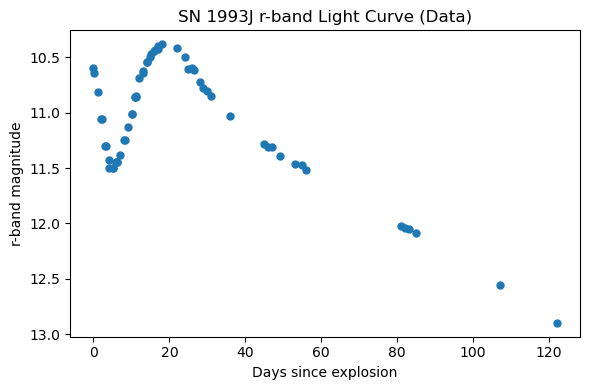

In [251]:
df_93 = pd.read_csv(os.path.expanduser("~/Downloads/sn1993j_rband_shifted.csv"))

plt.figure(figsize=(6,4))
plt.scatter(df_93["t_days"], df_93["R_app"], s=25)

plt.gca().invert_yaxis()
plt.xlabel("Days since explosion")
plt.ylabel("r-band magnitude")
plt.title("SN 1993J r-band Light Curve (Data)")
plt.tight_layout()
plt.show()


### Loading the AT2017gfo r-band Kilonova Data

This cell loads the real photometric data for the kilonova AT2017gfo.

- The file contains multi-band observations compiled from the literature.
- Each row corresponds to a measurement at a given time since merger (`Phase`).
- The `mag` column contains the observed apparent magnitude.
- The `Band` column specifies the filter (we will later isolate r-band only).

This dataset provides a fully data-driven kilonova light curve for direct comparison with the Type IIb supernova.


In [252]:
df_kn = pd.read_csv(os.path.expanduser("~/Downloads/at2017gfo_rband.csv"))
df_kn = df_kn[df_kn["Band"] == "r"].copy()
df_kn_r = df_kn   # alias used in later cells

print("Number of r-band points:", len(df_kn))

# Upper-limit mask: suspicious late-time points — define once, reuse everywhere
mask_kn = ((df_kn_r["Phase"] > 8) & (df_kn_r["mag"] < 20.5)) | (df_kn_r["Phase"] > 16)
kn_det = df_kn_r[~mask_kn]
kn_lim = df_kn_r[mask_kn]

df_kn.head()


Number of r-band points: 101


,MJD,Phase,Inst,Tel,Band,l_mag,mag,e_mag,Delta,Ref,Use,Avg,Rt,Out,Exc
2,57982.993,0.464,AltaU47+,Prompt5,r,NaN,17.46,0.03,0.00,2017ApJ...848L..24V,*,NaN,NaN,NaN,NaN
6,57983.000,0.471,LDSS,Magellan,r,NaN,17.33,0.02,0.00,2017arXiv171005443D,*,NaN,NaN,NaN,NaN
18,57983.028,0.499,AltaU47+,Prompt5,r,NaN,17.56,0.04,0.00,2017ApJ...848L..24V,*,NaN,NaN,NaN,NaN
24,57983.050,0.521,ROS2,REM,r,NaN,17.14,0.08,0.00,2017Natur.551...67P,*,NaN,NaN,NaN,NaN
38,57983.405,0.876,Sinistro,LCO1m,r,NaN,17.20,0.02,-0.02,2017Natur.551...64A,*,NaN,NaN,NaN,NaN


### Selecting Only r-band Kilonova Data

This cell filters the full AT2017gfo dataset to keep only r-band measurements.

- The original table contains multiple photometric bands.
- We restrict to rows where `Band == "r"`.
- A copy of the filtered dataframe is created to avoid modifying the original data.

This ensures we are comparing SN 2011dh and AT2017gfo in the same photometric band.


### AT2017gfo r-band Light Curve


We apply a physical sanity filter:

- Use r-band only  
- Respect published upper limits  
- After 8 days, any point brighter than 20.5 mag is treated as an upper limit  

This prevents artificial late-time rebrightening.


## Apparent r-band Light Curves

This cell plots the observed r-band light curves of SN 1993J and AT2017gfo.

- The x-axis shows time in days since explosion (SN 1993J) or merger (AT2017gfo).
- The y-axis shows apparent r-band magnitude.
- The y-axis is inverted because smaller magnitudes are brighter.
- Each point represents a real observational measurement.

This allows direct visual comparison between a Type IIb supernova and a kilonova in the same photometric band.

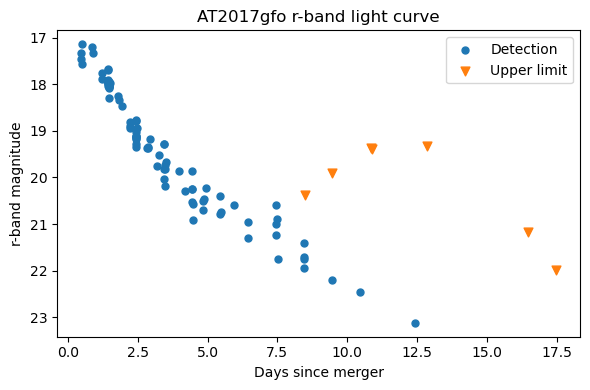

In [253]:
detections   = kn_det
upper_limits = kn_lim

plt.figure(figsize=(6,4))
plt.scatter(detections["Phase"], detections["mag"], s=25, label="Detection")
plt.scatter(upper_limits["Phase"], upper_limits["mag"], marker="v", s=40, label="Upper limit")

plt.gca().invert_yaxis()
plt.xlabel("Days since merger")
plt.ylabel("r-band magnitude")
plt.title("AT2017gfo r-band light curve")
plt.legend()
plt.tight_layout()
plt.show()


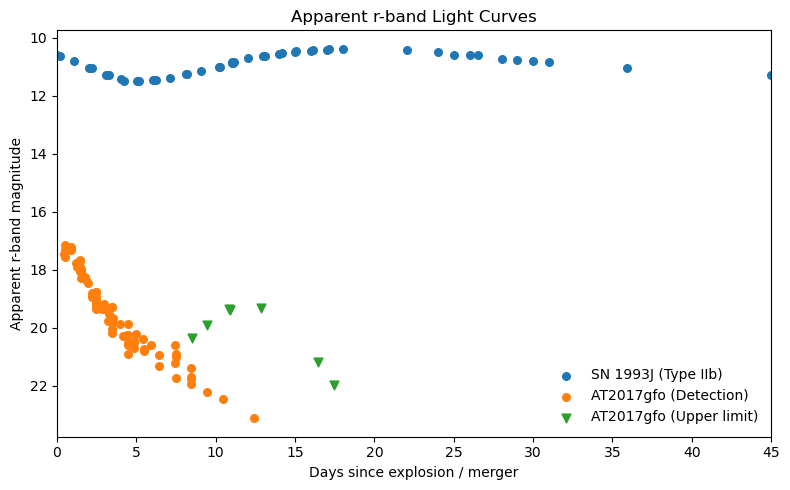

In [254]:
phase_sn = df_93["t_days"]
r_sn = df_93["R_app"]

phase_kn_det = kn_det["Phase"]
r_kn_det = kn_det["mag"]
phase_kn_lim = kn_lim["Phase"]
r_kn_lim = kn_lim["mag"]

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, r_sn, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, r_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, r_kn_lim, marker="v", s=40, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Apparent r-band magnitude")
plt.title("Apparent r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 45)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


## Absolute r-band Light Curves

This cell converts both light curves to absolute magnitude.

- The distance modulus is computed using:
  μ = 5 log10(d_Mpc × 10^6) − 5
- SN 1993J is assumed to be at 3.6 Mpc.
- AT2017gfo is assumed to be at 40 Mpc.
- Absolute magnitude is computed as:
  M = m − μ

This allows direct physical comparison of intrinsic brightness.

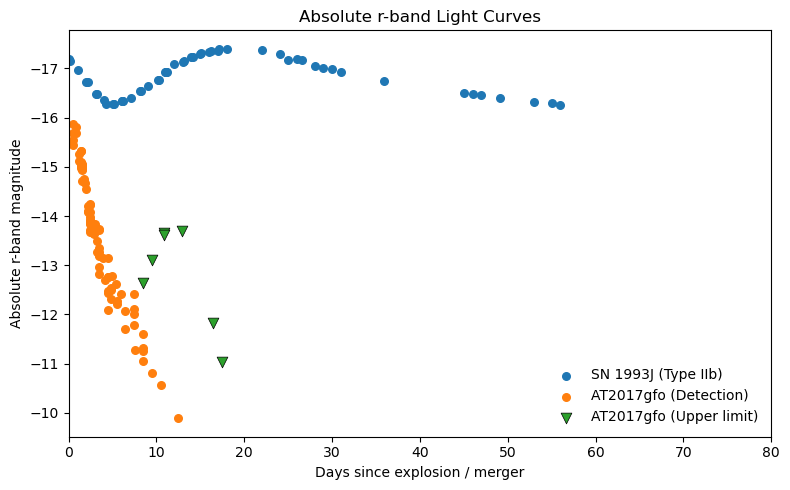

In [255]:
d_93 = 3.6    # Mpc
d_kn = 40.0   # Mpc

mu_93 = 5 * np.log10(d_93 * 1e6) - 5
mu_kn = 5 * np.log10(d_kn * 1e6) - 5

M_93      = r_sn - mu_93
M_kn_det  = r_kn_det - mu_kn
M_kn_lim  = r_kn_lim - mu_kn

plt.figure(figsize=(8,5))
plt.scatter(phase_sn, M_93, s=30, label="SN 1993J (Type IIb)")
plt.scatter(phase_kn_det, M_kn_det, s=30, label="AT2017gfo (Detection)")
plt.scatter(phase_kn_lim, M_kn_lim, marker="v", s=60, edgecolor="black", linewidth=0.5, label="AT2017gfo (Upper limit)")

plt.xlabel("Days since explosion / merger")
plt.ylabel("Absolute r-band magnitude")
plt.title("Absolute r-band Light Curves")
plt.gca().invert_yaxis()
plt.xlim(0, 80)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()


In [256]:
# --- Sort data before fitting splines ---

idx_sn = np.argsort(phase_sn)
phase_sn_sorted = phase_sn.values[idx_sn]
M_sn_sorted = M_93.values[idx_sn]

idx_kn = np.argsort(phase_kn_det)
phase_kn_sorted = phase_kn_det.values[idx_kn]
M_kn_sorted = M_kn_det.values[idx_kn]

# --- Fit splines ---

spline_sn = UnivariateSpline(phase_sn_sorted, M_sn_sorted, s=0.15)
spline_kn = UnivariateSpline(phase_kn_sorted, M_kn_sorted, s=3.9)

# Save raw splines BEFORE modifying them
_spline_sn_raw = spline_sn
_spline_kn_raw = spline_kn

# --- Evaluation grids ---

t_sn = np.linspace(phase_sn_sorted.min(), phase_sn_sorted.max(), 500)
t_kn = np.linspace(phase_kn_sorted.min(), phase_kn_sorted.max(), 500)

M_sn_smooth = _spline_sn_raw(t_sn)
M_kn_smooth = _spline_kn_raw(t_kn)

In [257]:
# --- Normalise both templates to the same peak absolute magnitude ---

M_peak = -16.0

sn_offset = M_peak - M_sn_smooth.min()
kn_offset = M_peak - M_kn_smooth.min()

# Apply offsets without modifying raw splines
spline_sn = lambda t: _spline_sn_raw(t) + sn_offset
spline_kn = lambda t: _spline_kn_raw(t) + kn_offset

print(f"SN template shifted by {sn_offset:+.2f} mag (raw peak was {M_sn_smooth.min():.2f})")
print(f"KN template shifted by {kn_offset:+.2f} mag (raw peak was {M_kn_smooth.min():.2f})")


# --- Residual-scatter uncertainty bands ---

sn_resid_std = np.std(M_sn_sorted - _spline_sn_raw(phase_sn_sorted))
kn_resid_std = np.std(M_kn_sorted - _spline_kn_raw(phase_kn_sorted))

SN_INTRINSIC_SCATTER = 0.2   # mag, Type IIb diversity
KN_INTRINSIC_SCATTER = 0.2  # mag, kilonova diversity

sn_band = np.sqrt(sn_resid_std**2 + SN_INTRINSIC_SCATTER**2)
kn_band = np.sqrt(kn_resid_std**2 + KN_INTRINSIC_SCATTER**2)

print(f"SN residual scatter: {sn_resid_std:.3f} mag → band (incl. intrinsic): {sn_band:.3f} mag")
print(f"KN residual scatter: {kn_resid_std:.3f} mag → band (incl. intrinsic): {kn_band:.3f} mag")

SN template shifted by +1.37 mag (raw peak was -17.37)
KN template shifted by -0.30 mag (raw peak was -15.70)
SN residual scatter: 0.050 mag → band (incl. intrinsic): 0.206 mag
KN residual scatter: 0.204 mag → band (incl. intrinsic): 0.285 mag


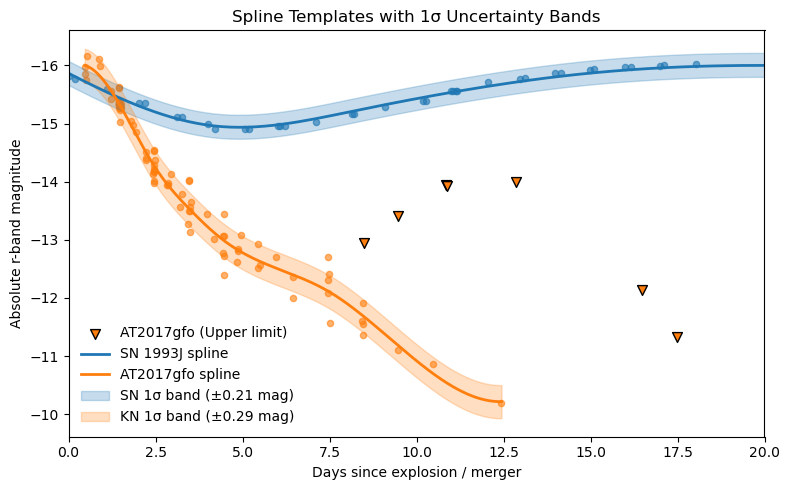

In [258]:
# Plot normalised splines with 1σ uncertainty bands
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(phase_sn_sorted, M_sn_sorted + sn_offset, s=20, alpha=0.6, color="C0")
ax.scatter(phase_kn_sorted, M_kn_sorted + kn_offset, s=20, alpha=0.6, color="C1")
ax.scatter(phase_kn_lim, M_kn_lim + kn_offset, marker="v", s=50, edgecolor="black", color="C1", label="AT2017gfo (Upper limit)")

ax.plot(t_sn, M_sn_smooth + sn_offset, linewidth=2, color="C0", label="SN 1993J spline")
ax.plot(t_kn, M_kn_smooth + kn_offset, linewidth=2, color="C1", label="AT2017gfo spline")

ax.fill_between(t_sn,
                M_sn_smooth + sn_offset - sn_band,
                M_sn_smooth + sn_offset + sn_band,
                alpha=0.25, color="C0", label=f"SN 1σ band (±{sn_band:.2f} mag)")
ax.fill_between(t_kn,
                M_kn_smooth + kn_offset - kn_band,
                M_kn_smooth + kn_offset + kn_band,
                alpha=0.25, color="C1", label=f"KN 1σ band (±{kn_band:.2f} mag)")

ax.set_xlim(0, 20)
ax.invert_yaxis()
ax.set_xlabel("Days since explosion / merger")
ax.set_ylabel("Absolute r-band magnitude")
ax.set_title("Spline Templates with 1σ Uncertainty Bands")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

#### 24 Hour Survey Configuration

We simulate a 96 hour transient survey with daily cadence.

Observation epochs are defined at:
t = 0, 1,  days.

This represents the minimal time baseline required to test early light curve evolution differences between kilonovae and supernovae.

In [259]:
np.random.seed(37)


t_obs = np.array([0, 1,])  # days

# LSST single-visit r-band limiting magnitude
m_lim = 24.5


def sample_distance(d_min=50, d_max=300):
    """Draw a distance uniformly in volume (proportional to d^2 dd)."""
    u = np.random.uniform()
    return (d_min**3 + u * (d_max**3 - d_min**3)) ** (1 / 3)


### Observed Light Curve Model

For each injected event, the following steps are applied:

1. Evaluate the absolute magnitude template spline at rest-frame time.
2. Remove pre-explosion epochs (t < 0).
3. Convert to apparent magnitude using the distance modulus:
   μ = 5 log10(d_Mpc × 10^6) − 5
4. Apply magnitude-dependent photometric uncertainty:
   σ = 0.1 mag at 20 mag,
   σ = 0.2 mag at 21 mag,
   linear interpolation between.

Gaussian noise is added to produce observed magnitudes.

In [260]:
def generate_observed_lightcurve(event_type, t0, d_mpc):

    # Rest-frame time
    t_rest = t_obs - t0

    # Evaluate absolute magnitude template
    if event_type == "SN":
        M = spline_sn(t_rest)
    else:
        M = spline_kn(t_rest)

    # Remove pre-explosion epochs
    M = np.array(M)
    M[t_rest < 0] = np.nan

    # Convert to apparent magnitude
    mu = 5 * np.log10(d_mpc * 1e6) - 5
    m_true = M + mu

    # Magnitude-dependent photometric uncertainty (linear 0.1→0.2 over 20–21 mag)
    sigma = np.where(m_true <= 20, 0.1, np.where(m_true >= 21, 0.2, 0.1 + 0.1 * (m_true - 20)))

    # Add Gaussian noise
    m_obs = m_true + np.random.normal(0, sigma)

    return m_obs, sigma


### Injection of 1 Kilonova and 50 Supernovae

We inject:
- 1 kilonova
- 50 Type IIb supernovae

Distances are drawn uniformly between 50 and 300 Mpc.

Explosion times are drawn uniformly between −1 and 0 days,
allowing events to be partially evolved at first detection.

This configuration approximates the expected contamination level in a 1000 deg² survey over 96 hours.

In [261]:
# --- Kilonova ---
kn_distance = sample_distance()
kn_t0 = np.random.uniform(-1, 0)
kn_lc, kn_sigma = generate_observed_lightcurve("KN", kn_t0, kn_distance)
kn_lc[kn_lc > m_lim] = np.nan   # epochs below limiting magnitude → non-detection

print(f"KN: d = {kn_distance:.1f} Mpc,  detected epochs = {np.sum(~np.isnan(kn_lc))} / {len(t_obs)}")

# --- Supernovae ---
sn_lcs = []
sn_sigmas = []

for _ in range(50):
    d = sample_distance()
    t0 = np.random.uniform(-1, 0)
    m_obs, sig = generate_observed_lightcurve("SN", t0, d)
    m_obs[m_obs > m_lim] = np.nan   # apply limiting magnitude
    sn_lcs.append(m_obs)
    sn_sigmas.append(sig)


KN: d = 294.4 Mpc,  detected epochs = 2 / 2


### 24-Hour Light Curve Comparison

Observed light curves are plotted over the four survey epochs.

Supernovae are shown in grey.
The kilonova is shown in red.

Over a 3 day baseline:
- Supernovae exhibit minimal magnitude evolution.
- Kilonovae exhibit rapid fading.

Separation between populations is therefore driven primarily by the measured light curve slope.

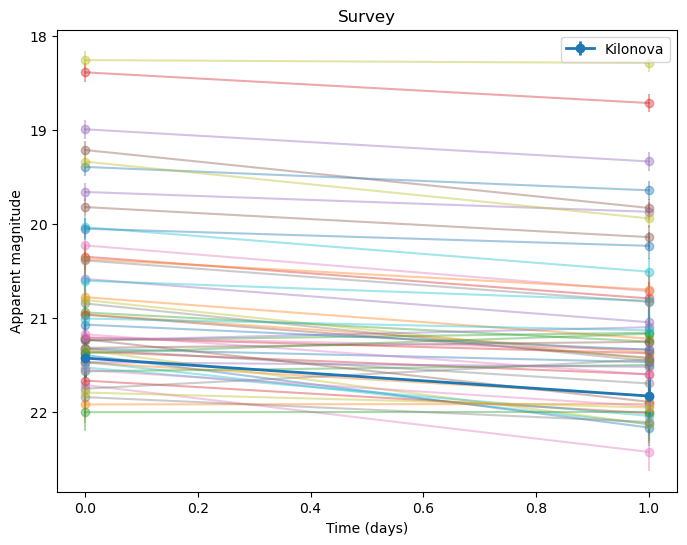

In [262]:
plt.figure(figsize=(8,6))

# Supernovae
for lc, sig in zip(sn_lcs, sn_sigmas):
    plt.errorbar(t_obs, lc, yerr=sig, fmt='o-', alpha=0.4)

# Kilonova
plt.errorbar(t_obs, kn_lc, yerr=kn_sigma, fmt='o-', linewidth=2, label="Kilonova")

plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Apparent magnitude")
plt.title("Survey")
plt.legend()
plt.show()

### Fade-Rate Classifier

To separate kilonovae from supernovae, a simple classifier based on how fast the light curve fades was used. Kilonovae fade much faster than supernovae during the first few days after peak brightness.

For each simulated light curve, the fade rate was estimated by comparing the brightness at the first detected observation and the last detected observation. Only valid detections were used. If fewer than two detections were available, the fade rate could not be calculated.

A threshold of **0.35 magnitudes per day** was used for classification.  
- If an event faded faster than this threshold, it was classified as a **kilonova candidate**.  
- If it faded more slowly, it was classified as a **supernova**.

The histogram shows the distribution of fade rates measured for the simulated supernova population. The red vertical line marks the fade rate of the injected kilonova, and the dashed black line shows the classification threshold.

KN fade rate : 0.584 mag/day  →  KN ✓
SN fade rates: ['0.142', '0.442', '0.311', '0.241', '0.211', '-0.065', '0.488', '0.615', '0.031', '0.664', '0.773', '0.354', '-0.066', '0.165', '0.460', '0.617', '0.713', '0.366', '0.631', '0.474', '0.183', '0.404', '-0.081', '0.347', '0.050', '0.458', '0.429', '-0.309', '0.787', '0.515', '0.249', '-0.005', '-0.002', '0.445', '-0.140', '0.666', '0.129', '0.265', '0.605', '0.214', '0.267', '0.325', '-0.206', '0.327', '0.343', '0.320', '0.385', '0.442', '0.159', '0.126']
SN false positives (misclassified as KN): 22 / 50


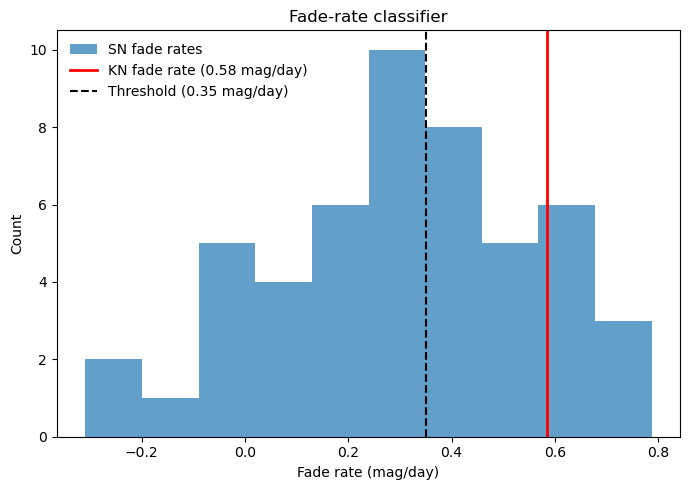

In [269]:
# --- Fade-rate classifier ---
# Kilonovae fade > ~0.5 mag/day in r-band; 
KN_FADE_THRESHOLD = 0.35  # mag/day


def fade_rate(m_obs):
    """Linear fade rate (mag/day) over detected epochs. Returns NaN if < 2 detections."""
    valid = ~np.isnan(m_obs)
    if valid.sum() < 2:
        return np.nan
    t_valid = t_obs[valid]
    m_valid = m_obs[valid]
    # Positive = fading (getting fainter)
    return (m_valid[-1] - m_valid[0]) / (t_valid[-1] - t_valid[0])


kn_rate = fade_rate(kn_lc)
sn_rates = np.array([fade_rate(lc) for lc in sn_lcs])

# Classify
kn_label = "KN ✓" if (not np.isnan(kn_rate) and kn_rate > KN_FADE_THRESHOLD) else "SN ✗ (missed)"
sn_fp = np.sum(sn_rates[~np.isnan(sn_rates)] > KN_FADE_THRESHOLD)
sn_valid = np.sum(~np.isnan(sn_rates))

print(f"KN fade rate : {kn_rate:.3f} mag/day  →  {kn_label}")
print(f"SN fade rates: {[f'{r:.3f}' for r in sn_rates if not np.isnan(r)]}")
print(f"SN false positives (misclassified as KN): {sn_fp} / {sn_valid}")

# Plot fade-rate distributions
fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(sn_rates[~np.isnan(sn_rates)], bins=10, label="SN fade rates", alpha=0.7)
if not np.isnan(kn_rate):
    ax.axvline(kn_rate, color="red", linewidth=2, label=f"KN fade rate ({kn_rate:.2f} mag/day)")
ax.axvline(KN_FADE_THRESHOLD, color="black", linestyle="--", label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
ax.set_xlabel("Fade rate (mag/day)")
ax.set_ylabel("Count")
ax.set_title("Fade-rate classifier")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


### Multi-Seed Survey Simulation

The survey was simulated **100 times with different random seeds**.

In each simulation:

- **1 kilonova** and **50 supernovae** were injected at random distances and explosion times.
- Light curves were generated using the survey cadence and limiting magnitude.
- Fade rates were calculated and the same **0.35 mag/day threshold** was used for classification.

In [264]:
# --- Multi-seed survey simulation (seeds 1–100) ---
# Re-uses all existing functions and parameters unchanged.

results = []

for seed in range(1, 101):
    np.random.seed(seed)

    # Inject 1 KN
    kn_d = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_lc, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_lc[kn_lc > m_lim] = np.nan

    # Inject 50 SNe
    sn_rates_seed = []
    for _ in range(50):
        d = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_obs, _ = generate_observed_lightcurve("SN", t0, d)
        m_obs[m_obs > m_lim] = np.nan
        sn_rates_seed.append(fade_rate(m_obs))

    kn_r = fade_rate(kn_lc)
    sn_r = np.array(sn_rates_seed)

    results.append({
        "seed":               seed,
        "kn_distance":        kn_d,
        "kn_fade_rate":       kn_r,
        "kn_detected":        (not np.isnan(kn_r)) and (kn_r > KN_FADE_THRESHOLD),
        "sn_false_positives": int(np.sum(sn_r[~np.isnan(sn_r)] > KN_FADE_THRESHOLD)),
        "sn_valid":           int(np.sum(~np.isnan(sn_r))),
    })

results_df = pd.DataFrame(results)
print(f"KN detection rate:       {results_df['kn_detected'].mean()*100:.1f}%  "
      f"({results_df['kn_detected'].sum()} / 100 seeds)")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f} per realisation")


KN detection rate:       80.0%  (80 / 100 seeds)
Mean SN false positives: 19.37 per realisation


In [ ]:
# --- Bootstrap confidence intervals on detection rate (100 resamples) ---
n_seeds = len(results_df)
kn_detected_arr = results_df["kn_detected"].values
sn_fp_arr = results_df["sn_false_positives"].values

rng = np.random.default_rng(42)
boot_kn_rate = []
boot_sn_fp   = []
for _ in range(100):
    idx = rng.integers(0, n_seeds, size=n_seeds)
    boot_kn_rate.append(kn_detected_arr[idx].mean())
    boot_sn_fp.append(sn_fp_arr[idx].mean())

boot_kn_rate = np.array(boot_kn_rate)
boot_sn_fp   = np.array(boot_sn_fp)

kn_lo, kn_hi = np.percentile(boot_kn_rate, [2.5, 97.5])
fp_lo, fp_hi = np.percentile(boot_sn_fp,   [2.5, 97.5])

print(f"KN detection rate: {results_df['kn_detected'].mean()*100:.1f}%  "
      f"95% CI: [{kn_lo*100:.1f}%, {kn_hi*100:.1f}%]")
print(f"Mean SN false positives: {results_df['sn_false_positives'].mean():.2f}  "
      f"95% CI: [{fp_lo:.2f}, {fp_hi:.2f}]")

### Classifier Performance Across 100 Simulations

The performance of the fade-rate classifier was examined using 100 independent survey simulations.

The left panel shows the distribution of measured kilonova fade rates. The dashed line marks the classification threshold of **0.35 mag/day**. 

The middle panel shows the number of supernovae that are incorrectly classified as kilonovae in each simulation. On average, several fast-fading supernovae contaminate the kilonova sample.

The right panel shows kilonova fade rate as a function of distance. Orange points indicate correctly detected kilonovae, while grey points show missed events. Missed detections occur when the measured fade rate falls below the classification threshold.

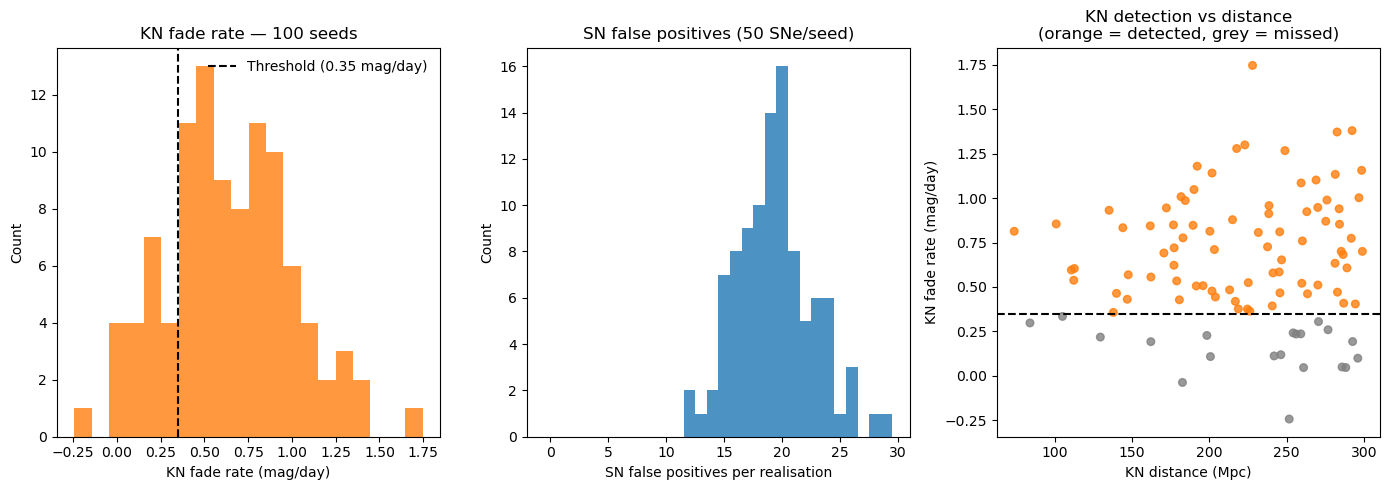

In [265]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
# Panel 1 — KN fade-rate distribution
axes[0].hist(results_df["kn_fade_rate"].dropna(), bins=20, color="C1", alpha=0.8)
axes[0].axvline(KN_FADE_THRESHOLD, color="black", linestyle="--",
                label=f"Threshold ({KN_FADE_THRESHOLD} mag/day)")
axes[0].set_xlabel("KN fade rate (mag/day)")
axes[0].set_ylabel("Count")
axes[0].set_title("KN fade rate — 100 seeds")
axes[0].legend(frameon=False)

# Panel 2 — SN false-positive count per realisation
fp_max = max(results_df["sn_false_positives"].max(), 1)
axes[1].hist(results_df["sn_false_positives"], bins=range(0, fp_max + 2),
             color="C0", alpha=0.8, align="left")
axes[1].set_xlabel("SN false positives per realisation")
axes[1].set_ylabel("Count")
axes[1].set_title("SN false positives (50 SNe/seed)")

# Panel 3 — KN detection vs distance
colors = results_df["kn_detected"].map({True: "C1", False: "grey"})
axes[2].scatter(results_df["kn_distance"], results_df["kn_fade_rate"],
                c=colors, s=30, alpha=0.8)
axes[2].axhline(KN_FADE_THRESHOLD, color="black", linestyle="--")
axes[2].set_xlabel("KN distance (Mpc)")
axes[2].set_ylabel("KN fade rate (mag/day)")
axes[2].set_title("KN detection vs distance\n(orange = detected, grey = missed)")

plt.tight_layout()
plt.show()

### Detection Efficiency vs Distance

This cell shows how the kilonova detection fraction varies with injected distance.

- Galaxies are binned in 50 Mpc steps from 50 to 300 Mpc.
- The fraction of seeds where the KN was detected is shown in each bin.
- The theoretical apparent magnitude of the KN template peak is overlaid,
  showing how detection drops once the peak approaches the limiting magnitude m_lim = 24.5.

Events near the survey boundary (d ~ 300 Mpc) become too faint to trigger the fade-rate
classifier with sufficient signal-to-noise, driving down detection efficiency.

In [ ]:
# --- Detection efficiency vs distance ---
bin_edges = np.arange(50, 351, 50)          # [50, 100, 150, 200, 250, 300, 350] Mpc
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

det_frac = []
det_counts = []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (results_df["kn_distance"] >= lo) & (results_df["kn_distance"] < hi)
    n_in_bin = mask.sum()
    det_counts.append(n_in_bin)
    if n_in_bin > 0:
        det_frac.append(results_df.loc[mask, "kn_detected"].mean())
    else:
        det_frac.append(np.nan)

det_frac = np.array(det_frac)

# Theoretical apparent magnitude of the KN template peak vs distance
d_grid = np.linspace(50, 350, 300)
mu_grid = 5 * np.log10(d_grid * 1e6) - 5
m_peak_grid = -16.0 + mu_grid    # M_peak = -16 assumed throughout

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.bar(bin_centers, det_frac, width=40, alpha=0.7, color="C1", label="KN detection fraction")
ax1.axhline(results_df["kn_detected"].mean(), color="C1", linestyle="--",
            linewidth=1.5, label=f"Overall mean ({results_df['kn_detected'].mean()*100:.0f}%)")
ax1.set_xlabel("KN distance (Mpc)")
ax1.set_ylabel("Detection fraction", color="C1")
ax1.tick_params(axis="y", labelcolor="C1")
ax1.set_ylim(0, 1.15)
ax1.set_xlim(50, 350)

ax2 = ax1.twinx()
ax2.plot(d_grid, m_peak_grid, color="C0", linewidth=2, label="Peak apparent magnitude (M=-16)")
ax2.axhline(m_lim, color="C0", linestyle=":", linewidth=1.5, label=f"Limiting magnitude ({m_lim})")
ax2.set_ylabel("Peak apparent magnitude", color="C0")
ax2.tick_params(axis="y", labelcolor="C0")
ax2.invert_yaxis()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, frameon=False, fontsize=9, loc="lower left")

ax1.set_title("KN Detection Efficiency vs Distance")
plt.tight_layout()
plt.show()

# Print bin summary
print(f"{'Bin (Mpc)':<16} {'N seeds':>8} {'Det frac':>10}")
for lo, hi, n, f in zip(bin_edges[:-1], bin_edges[1:], det_counts, det_frac):
    fstr = f"{f:.2f}" if not np.isnan(f) else "  n/a"
    print(f"  {lo:>3}–{hi:<3} Mpc        {n:>5}     {fstr:>8}")

### ROC and Classification Performance

To evaluate the classifier more systematically, the 100-seed simulation was repeated and the fade rate for every detected event was stored together with its true label (kilonova or supernova).

In each simulation one kilonova and fifty supernovae were generated. The fade rate was calculated for every light curve with at least two detections. Events with invalid measurements were ignored.

These values were then used to build a dataset containing the fade rate and the true class for each event. This allows the classifier to be evaluated across a range of possible thresholds.

Using this dataset, Receiver Operating Characteristic (ROC) curves can be calculated. These curves show how the performance of the fade-rate classifier changes as the threshold is varied, and allow the trade-off between kilonova detection efficiency and supernova contamination to be examined.

In [266]:
# --- ROC curve
# Re-run 100-seed simulation to collect per-event fade rates with true labels.
# (results_df only stores per-seed aggregates, not individual SN rates.)

all_scores = []   # fade rate for every event
all_labels = []   # 1 = KN, 0 = SN

for seed in range(1, 101):
    np.random.seed(seed)

    # KN
    kn_d = sample_distance()
    kn_t0 = np.random.uniform(-1, 0)
    kn_lc_s, _ = generate_observed_lightcurve("KN", kn_t0, kn_d)
    kn_lc_s[kn_lc_s > m_lim] = np.nan
    r = fade_rate(kn_lc_s)
    if not np.isnan(r):
        all_scores.append(r)
        all_labels.append(1)

    # 50 SNe
    for _ in range(50):
        d = sample_distance()
        t0 = np.random.uniform(-1, 0)
        m_obs_s, _ = generate_observed_lightcurve("SN", t0, d)
        m_obs_s[m_obs_s > m_lim] = np.nan
        r = fade_rate(m_obs_s)
        if not np.isnan(r):
            all_scores.append(r)
            all_labels.append(0)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

n_kn = (all_labels == 1).sum()
n_sn = (all_labels == 0).sum()




### ROC Curve Calculation

The classifier threshold is scanned across the full range of measured fade rates. For each threshold, events with a fade rate above the threshold are classified as kilonova candidates.

At every threshold the fraction of real kilonovae correctly identified and the fraction of supernovae incorrectly classified as kilonovae are calculated.

These values are used to construct the Receiver Operating Characteristic (ROC) curve. The ROC curve shows how the detection efficiency changes as the classification threshold is varied.

The area under the ROC curve (AUC) is then computed to summarise the overall performance of the classifier. A value close to one indicates strong separation between kilonovae and supernovae.

Finally, the operating point corresponding to the adopted threshold of **0.35 mag/day** is identified on the ROC curve.

In [267]:
# Sweep thresholds from min to max fade rate
thresholds = np.linspace(all_scores.min() - 0.01, all_scores.max() + 0.01, 500)

tpr_vals, fpr_vals, prec_vals = [], [], []
for t in thresholds:
    pred_pos = all_scores >= t
    tp = ((pred_pos) & (all_labels == 1)).sum()
    fp = ((pred_pos) & (all_labels == 0)).sum()
    tpr_vals.append(tp / n_kn if n_kn > 0 else 0)
    fpr_vals.append(fp / n_sn if n_sn > 0 else 0)
    prec_vals.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)

tpr_vals  = np.array(tpr_vals)
fpr_vals  = np.array(fpr_vals)
prec_vals = np.array(prec_vals)

# AUC via trapezoidal rule (sort by FPR for proper integration)
sort_idx = np.argsort(fpr_vals)
auc = np.trapezoid(tpr_vals[sort_idx], fpr_vals[sort_idx])

# Mark operating point at KN_FADE_THRESHOLD
op_idx = np.argmin(np.abs(thresholds - KN_FADE_THRESHOLD))
op_fpr  = fpr_vals[op_idx]
op_tpr  = tpr_vals[op_idx]
op_prec = prec_vals[op_idx]
op_rec  = tpr_vals[op_idx]   # recall = TPR

In [ ]:
# --- Bootstrap confidence interval on AUC (100 resamples) ---
kn_scores = all_scores[all_labels == 1]
sn_scores = all_scores[all_labels == 0]

boot_aucs = []
rng2 = np.random.default_rng(42)
for _ in range(100):
    kn_boot = rng2.choice(kn_scores, size=len(kn_scores), replace=True)
    sn_boot = rng2.choice(sn_scores, size=len(sn_scores), replace=True)
    boot_all_scores = np.concatenate([kn_boot, sn_boot])
    boot_all_labels = np.concatenate([np.ones(len(kn_boot)), np.zeros(len(sn_boot))])

    boot_tpr, boot_fpr = [], []
    for t in thresholds:
        pred = boot_all_scores >= t
        tp = ((pred) & (boot_all_labels == 1)).sum()
        fp = ((pred) & (boot_all_labels == 0)).sum()
        boot_tpr.append(tp / len(kn_boot) if len(kn_boot) > 0 else 0)
        boot_fpr.append(fp / len(sn_boot) if len(sn_boot) > 0 else 0)

    s = np.argsort(boot_fpr)
    boot_aucs.append(np.trapezoid(np.array(boot_tpr)[s], np.array(boot_fpr)[s]))

auc_lo, auc_hi = np.percentile(boot_aucs, [2.5, 97.5])
print(f"AUC = {auc:.3f}  95% CI: [{auc_lo:.3f}, {auc_hi:.3f}]")

In [ ]:
fig, ax = plt.subplots(figsize=(8,7))

ax.plot(fpr_vals, tpr_vals, linewidth=2, label=f"ROC (AUC = {auc:.3f}, 95% CI [{auc_lo:.3f}–{auc_hi:.3f}])")
ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random classifier")

ax.scatter([op_fpr], [op_tpr], s=80, zorder=5,
           label=f"Threshold = {KN_FADE_THRESHOLD} mag/day\n"
                 f"(TPR={op_tpr:.2f}, FPR={op_fpr:.2f})")

ax.set_xlabel("False Positive Rate (SN contamination)")
ax.set_ylabel("True Positive Rate (KN completeness)")
ax.set_title("ROC Curve – Fade-rate classifier")
ax.legend(frameon=False, fontsize=9)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

### Precision-Recall Curve

For class-imbalanced datasets the Precision-Recall (PR) curve is more informative than the ROC curve because it directly shows the trade-off between purity and completeness of the kilonova sample.

- **Precision** = fraction of KN candidates that are real KN (purity)
- **Recall** = fraction of real KN that are recovered (completeness / TPR)

At the adopted threshold the imbalance is extreme (1 KN vs 50 SNe per seed), so precision remains low even at high recall. The area under the PR curve (AUCPR) summarises this trade-off. A no-skill classifier would achieve AUCPR ≈ 1/(1+50) ≈ 0.02; any value substantially above this indicates the classifier is useful.

In [ ]:
# --- Precision-Recall curve ---
# prec_vals and tpr_vals already computed over the same threshold sweep

# Sort by recall (TPR) for proper PR curve integration
sort_rec = np.argsort(tpr_vals)
rec_sorted  = tpr_vals[sort_rec]
prec_sorted = prec_vals[sort_rec]

# Area under the PR curve (trapezoidal)
auc_pr = np.trapezoid(prec_sorted, rec_sorted)

# No-skill baseline: fraction of positives in the dataset
baseline_pr = (all_labels == 1).mean()

# Operating point at KN_FADE_THRESHOLD
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: ROC
axes[0].plot(fpr_vals, tpr_vals, linewidth=2,
             label=f"ROC (AUC = {auc:.3f}, 95% CI [{auc_lo:.3f}–{auc_hi:.3f}])")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
axes[0].scatter([op_fpr], [op_tpr], s=80, zorder=5,
                label=f"Threshold = {KN_FADE_THRESHOLD} mag/day\n(TPR={op_tpr:.2f}, FPR={op_fpr:.2f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# Right: PR
axes[1].plot(rec_sorted, prec_sorted, linewidth=2, color="C1",
             label=f"PR curve (AUCPR = {auc_pr:.3f})")
axes[1].axhline(baseline_pr, color="grey", linestyle="--", linewidth=1,
                label=f"No-skill baseline ({baseline_pr:.3f})")
axes[1].scatter([op_tpr], [op_prec], s=80, zorder=5, color="C1",
                label=f"Threshold = {KN_FADE_THRESHOLD} mag/day\n"
                      f"(Recall={op_rec:.2f}, Prec={op_prec:.3f})")
axes[1].set_xlabel("Recall (KN completeness)")
axes[1].set_ylabel("Precision (KN purity)")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(frameon=False, fontsize=8)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.suptitle("Classifier Performance Summary", fontsize=12)
plt.tight_layout()
plt.show()

print(f"AUCPR = {auc_pr:.3f}  (no-skill baseline = {baseline_pr:.3f})")

### Optimal Classifier Threshold

The fade-rate threshold of 0.35 mag/day was chosen heuristically. We can now derive it formally from the ROC data using two standard optimality criteria:

- **Youden's J statistic**: J = TPR − FPR. Maximised when the classifier best separates the two populations regardless of class imbalance.
- **F₁ score**: F₁ = 2·Precision·Recall / (Precision + Recall). Maximised when the harmonic mean of purity and completeness is highest. More sensitive to the class imbalance (1 KN : 50 SN).

Comparing these derived optima to the hardcoded threshold validates (or suggests refining) the operating point.

In [ ]:
# --- Optimal threshold derivation from existing ROC data ---
youden_j = tpr_vals - fpr_vals
f1_vals  = np.where(
    (prec_vals + tpr_vals) > 0,
    2 * prec_vals * tpr_vals / (prec_vals + tpr_vals),
    0.0
)

thresh_youden = thresholds[np.argmax(youden_j)]
thresh_f1     = thresholds[np.argmax(f1_vals)]

print(f"Youden-J optimal threshold : {thresh_youden:.3f} mag/day  (J = {youden_j.max():.3f})")
print(f"F\u2081-optimal threshold      : {thresh_f1:.3f} mag/day  (F\u2081 = {f1_vals.max():.3f})")
print(f"Current hardcoded threshold : {KN_FADE_THRESHOLD:.3f} mag/day")

# --- Figure: J and F1 vs threshold ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(thresholds, youden_j, linewidth=2, color="C0", label="Youden's J  (TPR \u2212 FPR)")
ax.plot(thresholds, f1_vals,  linewidth=2, color="C1", label="F\u2081 score")

ax.axvline(thresh_youden,    color="C0", linestyle="--", linewidth=1.2,
           label=f"Youden optimal ({thresh_youden:.3f} mag/day)")
ax.axvline(thresh_f1,        color="C1", linestyle="--", linewidth=1.2,
           label=f"F\u2081 optimal ({thresh_f1:.3f} mag/day)")
ax.axvline(KN_FADE_THRESHOLD, color="k",  linestyle=":",  linewidth=1.5,
           label=f"Current threshold ({KN_FADE_THRESHOLD} mag/day)")

ax.set_xlabel("Fade-rate threshold (mag/day)")
ax.set_ylabel("Score")
ax.set_title("Threshold Optimisation — Youden's J and F\u2081 Score")
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(thresholds.min(), thresholds.max())
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## Survey Sensitivity Analysis

All results so far used fixed survey parameters: limiting magnitude m_lim = 24.5 and a 2-epoch cadence (t = 0, 1 days). These were motivated by LSST single-visit performance, but the optimal survey design is an open question.

This section sweeps over:

- **Limiting magnitude** — from 22.0 to 25.5 in 0.5 mag steps, spanning from shallow (current ZTF-like) to deep (LSST-optimistic)
- **Cadence** — 2, 3, or 4 nightly epochs

For each combination the full 100-seed simulation is re-run and three figures of merit are recorded:

1. **KN detection rate** — fraction of seeds where the kilonova is correctly classified
2. **Mean SN false positives** — average contamination per realisation
3. **AUC** — overall classifier discrimination across all thresholds

The result directly answers the survey design question: *how much does detection improve with depth or cadence, and where does performance saturate?*

In [ ]:
def _lc_noise(m_true):
    """Magnitude-dependent photometric uncertainty (same model as generate_observed_lightcurve)."""
    return np.where(m_true <= 20, 0.1,
                    np.where(m_true >= 21, 0.2, 0.1 + 0.1 * (m_true - 20)))


def _fade_rate_generic(m_obs, t_arr):
    """Linear fade rate over detected epochs; NaN if < 2 detections."""
    valid = ~np.isnan(m_obs)
    if valid.sum() < 2:
        return np.nan
    return (m_obs[valid][-1] - m_obs[valid][0]) / (t_arr[valid][-1] - t_arr[valid][0])


def run_survey(t_obs_arr, m_lim_val, n_seeds=100, n_sn=50, threshold=None):
    """
    Run the multi-seed survey simulation for arbitrary cadence and limiting magnitude.

    Parameters
    ----------
    t_obs_arr : array-like
        Observation epochs in days (e.g. [0, 1] or [0, 1, 2]).
    m_lim_val : float
        Single-visit limiting magnitude.
    n_seeds : int
        Number of independent realisations.
    n_sn : int
        Supernovae injected per seed.
    threshold : float or None
        Fade-rate classification threshold (mag/day).
        Defaults to global KN_FADE_THRESHOLD.

    Returns
    -------
    dict with keys: kn_det_rate, sn_fp_mean, auc
    """
    t_arr = np.asarray(t_obs_arr, dtype=float)
    thresh = KN_FADE_THRESHOLD if threshold is None else threshold

    # --- per-seed results ---
    kn_detected_list = []
    sn_fp_list       = []

    # --- for AUC: collect per-event scores + labels across all seeds ---
    ev_scores = []
    ev_labels = []

    for seed in range(1, n_seeds + 1):
        np.random.seed(seed)

        # ---- Kilonova ----
        kn_d  = sample_distance()
        kn_t0 = np.random.uniform(-1, 0)
        t_rest_kn = t_arr - kn_t0
        M_kn = np.array(spline_kn(t_rest_kn), dtype=float)
        M_kn[t_rest_kn < 0] = np.nan
        mu_kn    = 5 * np.log10(kn_d * 1e6) - 5
        m_true_kn = M_kn + mu_kn
        sig_kn   = _lc_noise(m_true_kn)
        m_obs_kn = m_true_kn + np.random.normal(0, np.where(np.isnan(sig_kn), 0, sig_kn))
        m_obs_kn[np.isnan(M_kn) | (m_obs_kn > m_lim_val)] = np.nan

        kn_r = _fade_rate_generic(m_obs_kn, t_arr)
        kn_det = (not np.isnan(kn_r)) and (kn_r > thresh)
        kn_detected_list.append(kn_det)
        if not np.isnan(kn_r):
            ev_scores.append(kn_r); ev_labels.append(1)

        # ---- Supernovae ----
        sn_fp_count = 0
        for _ in range(n_sn):
            d   = sample_distance()
            t0  = np.random.uniform(-1, 0)
            t_rest_sn = t_arr - t0
            M_sn = np.array(spline_sn(t_rest_sn), dtype=float)
            M_sn[t_rest_sn < 0] = np.nan
            mu_sn    = 5 * np.log10(d * 1e6) - 5
            m_true_sn = M_sn + mu_sn
            sig_sn   = _lc_noise(m_true_sn)
            m_obs_sn = m_true_sn + np.random.normal(0, np.where(np.isnan(sig_sn), 0, sig_sn))
            m_obs_sn[np.isnan(M_sn) | (m_obs_sn > m_lim_val)] = np.nan
            r = _fade_rate_generic(m_obs_sn, t_arr)
            if not np.isnan(r):
                ev_scores.append(r); ev_labels.append(0)
                if r > thresh:
                    sn_fp_count += 1
        sn_fp_list.append(sn_fp_count)

    # --- AUC ---
    ev_scores = np.array(ev_scores)
    ev_labels = np.array(ev_labels)
    n_kn_ev = (ev_labels == 1).sum()
    n_sn_ev = (ev_labels == 0).sum()

    if n_kn_ev > 0 and n_sn_ev > 0:
        thr_sweep = np.linspace(ev_scores.min() - 0.01, ev_scores.max() + 0.01, 300)
        tpr_s, fpr_s = [], []
        for thr in thr_sweep:
            pred = ev_scores >= thr
            tpr_s.append(((pred) & (ev_labels == 1)).sum() / n_kn_ev)
            fpr_s.append(((pred) & (ev_labels == 0)).sum() / n_sn_ev)
        s = np.argsort(fpr_s)
        auc_val = float(np.trapezoid(np.array(tpr_s)[s], np.array(fpr_s)[s]))
    else:
        auc_val = np.nan

    return {
        "kn_det_rate": np.mean(kn_detected_list),
        "sn_fp_mean":  np.mean(sn_fp_list),
        "auc":         auc_val,
    }

In [ ]:
# --- Parameter grid ---
m_lim_grid = np.arange(22.0, 26.0, 0.5)   # 22.0, 22.5, ..., 25.5

cadence_grid = {
    "2-epoch [0,1d]":     np.array([0, 1]),
    "3-epoch [0,1,2d]":   np.array([0, 1, 2]),
    "4-epoch [0,1,2,3d]": np.array([0, 1, 2, 3]),
}

# --- Run grid (24 combinations × 100 seeds each) ---
sens_rows = []

for cadence_label, t_obs_arr in cadence_grid.items():
    for ml in m_lim_grid:
        res = run_survey(t_obs_arr, ml, n_seeds=100)
        sens_rows.append({
            "cadence":     cadence_label,
            "m_lim":       ml,
            "kn_det_rate": res["kn_det_rate"],
            "sn_fp_mean":  res["sn_fp_mean"],
            "auc":         res["auc"],
        })
        print(f"  {cadence_label:24s}  m_lim={ml:.1f}  "
              f"det={res['kn_det_rate']*100:.0f}%  "
              f"FP={res['sn_fp_mean']:.1f}  "
              f"AUC={res['auc']:.3f}")

sens_df = pd.DataFrame(sens_rows)
print(f"\nGrid complete: {len(sens_df)} combinations")

In [ ]:
# --- 3-panel sensitivity figure ---
fig, axes = plt.subplots(3, 1, figsize=(9, 10), sharex=True)

colors    = {"2-epoch [0,1d]": "C0", "3-epoch [0,1,2d]": "C1", "4-epoch [0,1,2,3d]": "C2"}
markers   = {"2-epoch [0,1d]": "o",  "3-epoch [0,1,2d]": "s",  "4-epoch [0,1,2,3d]": "^"}
lsst_mlim = 24.5   # reference depth

for cadence_label in cadence_grid:
    sub = sens_df[sens_df["cadence"] == cadence_label].sort_values("m_lim")
    c   = colors[cadence_label]
    mk  = markers[cadence_label]

    axes[0].plot(sub["m_lim"], sub["kn_det_rate"] * 100,
                 color=c, marker=mk, linewidth=2, label=cadence_label)
    axes[1].plot(sub["m_lim"], sub["sn_fp_mean"],
                 color=c, marker=mk, linewidth=2)
    axes[2].plot(sub["m_lim"], sub["auc"],
                 color=c, marker=mk, linewidth=2)

# Reference lines
ref_det = results_df["kn_detected"].mean() * 100
for ax in axes:
    ax.axvline(lsst_mlim, color="grey", linestyle="--", linewidth=1.2,
               label=f"LSST reference (m_lim = {lsst_mlim})")

axes[0].axhline(ref_det, color="grey", linestyle=":", linewidth=1.0,
                label=f"2-epoch baseline ({ref_det:.0f}%)")

# Labels
axes[0].set_ylabel("KN detection rate (%)")
axes[0].set_title("Survey Sensitivity Analysis")
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_ylim(0, 105)

axes[1].set_ylabel("Mean SN false positives / seed")
axes[1].set_ylim(bottom=0)

axes[2].set_ylabel("AUC")
axes[2].set_xlabel("Limiting magnitude (m$_{\\rm lim}$)")
axes[2].set_ylim(0.4, 1.0)

plt.tight_layout()
plt.savefig("survey_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to survey_sensitivity.png")